# A tour of orhelper

This notebook runs OpenRocket simulations from Python: load a rocket, run it, look at the results, change things and run again.

You need [OpenRocket](https://openrocket.info/downloads.html) installed and `pip install orhelper matplotlib` (`pandas` is optional).

> **Restarting.** The Java virtual machine that runs OpenRocket can be started **once per kernel**. If you see `JVMAlreadyStartedError`, restart the kernel (*Kernel → Restart*) and run the cells again.

## 1. Start OpenRocket

In a script you wrap everything in `with orhelper.OpenRocketInstance() as instance:`. In a notebook you want OpenRocket to stay available between cells, so start it once and keep it running until the kernel stops.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np

import orhelper
from orhelper import FlightDataType

if "instance" not in globals():  # makes this cell safe to run twice
    # log_level="ERROR" hides OpenRocket's own (very chatty) logging.
    instance = orhelper.OpenRocketInstance(log_level="ERROR")
    instance.__enter__()

orh = orhelper.Helper(instance)

## 2. Load a rocket and run the simulation

`orhelper.sample_ork_path()` is a small sample rocket that ships with orhelper. To use your own, pass the path of a `.ork` file to `load_doc`.

The document, the rocket and the simulation are **Java objects**: you call their Java methods (`getRocket()`, `getSimulation(0)`, ...) directly.

In [2]:
doc = orh.load_doc(orhelper.sample_ork_path())
sim = doc.getSimulation(0)
print("Rocket:    ", doc.getRocket().getName())
print("Simulation:", sim.getName())

orh.run_simulation(sim)

Rocket:     A simple model rocket
Simulation: Simulation 1


## 3. Get the results

`get_timeseries` returns a dictionary with one NumPy array per variable. Ask for the variables you need with `FlightDataType`.

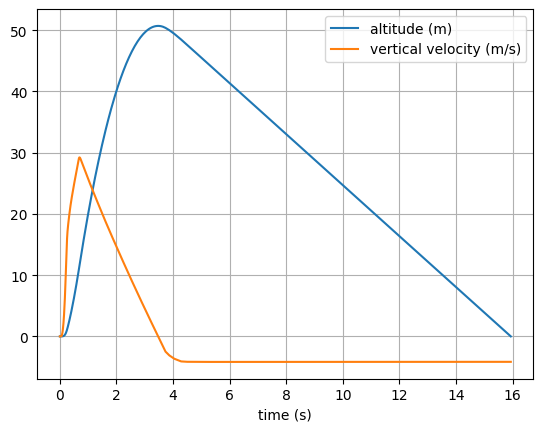

In [3]:
data = orh.get_timeseries(sim, [FlightDataType.TYPE_TIME,
                                FlightDataType.TYPE_ALTITUDE,
                                FlightDataType.TYPE_VELOCITY_Z])
time = data[FlightDataType.TYPE_TIME]

fig, ax = plt.subplots()
ax.plot(time, data[FlightDataType.TYPE_ALTITUDE], label="altitude (m)")
ax.plot(time, data[FlightDataType.TYPE_VELOCITY_Z], label="vertical velocity (m/s)")
ax.set_xlabel("time (s)")
ax.legend()
ax.grid(True)

`get_events` tells you when things happened: burnout, apogee, parachute deployment, ground hit...

In [4]:
events = orh.get_events(sim)
for event, times in events.items():
    print(f"{event.name:<28} {times[0]:6.2f} s")

LAUNCH                         0.00 s
IGNITION                       0.00 s
LIFTOFF                        0.11 s
LAUNCHROD                      0.25 s
BURNOUT                        0.73 s
APOGEE                         3.49 s
EJECTION_CHARGE                3.73 s
RECOVERY_DEVICE_DEPLOYMENT     3.73 s
GROUND_HIT                    15.93 s
SIMULATION_END                15.93 s


Some series contain `NaN` (for example, velocity at the very first time step), so use `np.nanmax` / `np.nanmin` for statistics.

In [5]:
speed = orh.get_timeseries(sim, [FlightDataType.TYPE_VELOCITY_TOTAL])[FlightDataType.TYPE_VELOCITY_TOTAL]
print(f"Apogee:       {np.max(data[FlightDataType.TYPE_ALTITUDE]):.1f} m")
print(f"Max velocity: {np.nanmax(speed):.1f} m/s")

Apogee:       50.7 m
Max velocity: 29.3 m/s


## 4. Change the launch conditions and run again

Simulation settings live in `sim.getOptions()`. Angles are in **radians**, speeds in m/s. Here we see how wind affects how far the rocket drifts.

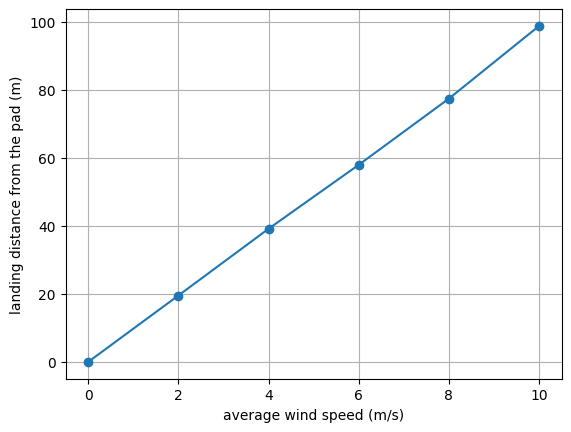

In [6]:
options = sim.getOptions()
options.setLaunchRodAngle(math.radians(0))

winds = np.arange(0, 11, 2)
drift = []
for wind in winds:
    options.setWindSpeedAverage(float(wind))
    orh.run_simulation(sim)
    position = orh.get_timeseries(sim, [FlightDataType.TYPE_POSITION_X, FlightDataType.TYPE_POSITION_Y])
    drift.append(math.hypot(position[FlightDataType.TYPE_POSITION_X][-1],
                            position[FlightDataType.TYPE_POSITION_Y][-1]))

fig, ax = plt.subplots()
ax.plot(winds, drift, "o-")
ax.set_xlabel("average wind speed (m/s)")
ax.set_ylabel("landing distance from the pad (m)")
ax.grid(True)

## 5. Change the rocket

`get_component_named` finds a part of the rocket by name. Then use its Java getters and setters. Here we make the nose cone 20 g heavier and compare the apogee (masses are in kg).

In [7]:
def apogee():
    orh.run_simulation(sim)
    altitude = orh.get_timeseries(sim, [FlightDataType.TYPE_ALTITUDE])[FlightDataType.TYPE_ALTITUDE]
    return np.max(altitude)

options.setWindSpeedAverage(0.0)
before = apogee()

nose = orh.get_component_named(doc.getRocket(), "Nose cone")
nose.setOverrideMass(nose.getMass() + 0.020)
nose.setMassOverridden(True)

print(f"Apogee: {before:.1f} m -> {apogee():.1f} m with a 20 g heavier nose cone")

Apogee: 51.2 m -> 30.2 m with a 20 g heavier nose cone


To keep your changes, save the document: `orh.save_doc("my_rocket.ork", doc)`.

## 6. Use the data with pandas (optional)

Because the results are plain NumPy arrays, they drop straight into a DataFrame.

In [8]:
import pandas as pd

variables = [FlightDataType.TYPE_TIME, FlightDataType.TYPE_ALTITUDE, FlightDataType.TYPE_VELOCITY_TOTAL]
series = orh.get_timeseries(sim, variables)
frame = pd.DataFrame({variable.name: values for variable, values in series.items()})
frame.describe().loc[["min", "max"]]

,TYPE_TIME,TYPE_ALTITUDE,TYPE_VELOCITY_TOTAL
min,0.000000,0.000000,0.000000
max,8.990752,30.217542,21.055355


## 7. Run your own code during the simulation

A *listener* is called by OpenRocket during the simulation. Subclass `AbstractSimulationListener`, override the hooks you need, and pass an instance to `run_simulation`.

In [9]:
class AltitudeTracker(orhelper.AbstractSimulationListener):
    """Record the altitude after every simulation step."""

    def __init__(self):
        self.altitudes = []

    def postStep(self, status):
        self.altitudes.append(status.getRocketPosition().z)  # z is up


tracker = AltitudeTracker()
orh.run_simulation(sim, listeners=[tracker])
print(f"The listener was called {len(tracker.altitudes)} times; highest altitude seen: {max(tracker.altitudes):.1f} m")

The listener was called 158 times; highest altitude seen: 30.2 m


## Where next?

* The [`examples/`](https://github.com/openrocket/orhelper/tree/master/examples) folder has scripts for parameter sweeps, multistage rockets, Monte Carlo studies and parallel runs.
* OpenRocket's own classes are documented in its [source code](https://github.com/openrocket/openrocket); use `dir(obj)` to see what a Java object offers.
* The [README](https://github.com/openrocket/orhelper#readme) has a troubleshooting section.